# Clustering: Welche Gruppen stecken in den Daten?

**Verfahren:** Clustering (unüberwachtes Lernen — es gibt kein „richtig“)  |  **Geschäftsfrage:** Welche Stationstypen und welche Kundensegmente hat VeloCity wirklich?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/03_Clustering_Stationen_und_Kunden.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

## Zwei Fragen, ein Verfahren

Dieses Notebook behandelt **zwei Aufgaben parallel**, weil beide dasselbe Verfahren
brauchen und der Vergleich lehrreicher ist als jede für sich:

| | Aufgabe | Objekte | wer wartet auf die Antwort |
|---|---|---|---|
| **A** | Stationstypen finden | 10 Stationen | Disposition — wo muss umverteilt werden? |
| **B** | Kundensegmente finden | 3.200 Kundinnen und Kunden | Marketing — wer bekommt welches Angebot? |

Sie werden sehen: **Die sechs Phasen sind identisch.** Was sich unterscheidet, sind die
Merkmale und die Deutung — nicht das Vorgehen.

## Was Clustering von den ersten beiden Notebooks unterscheidet

In Notebook 1 und 2 gab es eine **Zielspalte**: die Fahrtdauer, die Schadensmeldung.
Das Modell konnte sich an ihr messen, und wir konnten sagen, ob es richtig lag.

Hier gibt es **nichts dergleichen**. Niemand hat die Stationen je in Typen eingeteilt.
Es gibt keine Wahrheit zum Vergleichen, keine Trefferquote, keine Confusion-Matrix.

> **Das ist der Unterschied zwischen überwachtem und unüberwachtem Lernen** — und er hat
> Folgen bis in Phase 5 hinein: Die Bewertung eines Clusterings ist am Ende immer auch
> ein **fachliches Urteil**, kein rein rechnerisches.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Zwei Geschäftsfragen, für die es keine Zielgröße gibt — und trotzdem Erfolgskriterien geben muss.

### A — Die Disposition

VeloCity fährt jeden Morgen einen Transporter, der Räder umverteilt. Heute geschieht das
nach Gefühl: Der Fahrer sieht, wo wenig steht, und füllt auf. Das ist teuer und träge.

Die Dispositionsleitung will die zehn Stationen in **wenige Typen** einteilen und je Typ
eine Regel hinterlegen („Pendlerstationen bis 7 Uhr auffüllen, Freizeitstationen erst
gegen Mittag“). Dafür muss erst einmal klar sein, **welche Typen es überhaupt gibt**.

### B — Das Marketing

Der Newsletter geht heute an alle 3.200 Kundinnen und Kunden gleich. Die Öffnungsrate ist
entsprechend. Das Marketing möchte **drei bis fünf Segmente**, für die sich
unterschiedliche Ansprache lohnt.

### Die Erfolgskriterien — auch ohne Zielgröße

Das ist die schwierigste Stelle dieser Phase, und sie wird gerne übersprungen. Ein
Clustering-Ergebnis kann man nicht auf „richtig“ prüfen. Man kann aber sehr wohl vorher
festlegen, **wann es brauchbar ist**:

| | Kriterium | Warum |
|---|---|---|
| **1 Benennbarkeit** | Jede Gruppe muss sich in einem Satz beschreiben lassen, den ein Fachfremder versteht | Was man nicht benennen kann, kann man auch nicht bearbeiten |
| **2 Handlungsrelevanz** | Für jede Gruppe muss es eine **andere** Maßnahme geben | Zwei Gruppen mit derselben Maßnahme sind eine Gruppe |
| **3 Größe** | Keine Gruppe unter 5 % der Objekte | Ein Segment mit zwölf Kunden lohnt keine eigene Kampagne |
| **4 Stabilität** | Ein zweiter Lauf mit anderem Zufallsstart muss dieselben Gruppen liefern | Sonst ist es Zufall, kein Muster |

**Kriterium 2 ist das schärfste.** Es hat schon manches statistisch tadellose Clustering
zu Recht beerdigt.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Was wissen wir über Stationen und Kundschaft — und was davon beschreibt ihr *Verhalten* statt ihrer Stammdaten?

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/")
pd.set_option("display.width", 150)

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])
stationen = pd.read_csv(BASIS + "station.csv")
kunden = pd.read_csv(BASIS + "kunde.csv", parse_dates=["registriert_am"])
tarife = pd.read_csv(BASIS + "tarif.csv")
feiertage = set(pd.read_csv(BASIS + "feiertage.csv").datum)

echte = fahrten[fahrten.status == "abgeschlossen"].copy()
echte["datum"] = echte.startzeit.dt.strftime("%Y-%m-%d")
echte["stunde"] = echte.startzeit.dt.hour
echte["ist_frei"] = (echte.startzeit.dt.dayofweek >= 5) | echte.datum.isin(feiertage)

print("Stationen — das ist ALLES, was wir über sie wissen:")
print(stationen.to_string(index=False))

Stationen — das ist ALLES, was wir über sie wissen:
 station_id stationsnummer                   name  latitude  longitude  kapazitaet
          1         S-0001           Hauptbahnhof   49.8019     9.9358          40
          2         S-0002             Marktplatz   49.7944     9.9295          25
          3         S-0003 Universität Sanderring   49.7880     9.9353          35
          4         S-0004               Residenz   49.7930     9.9390          25
          5         S-0005        Juliuspromenade   49.7960     9.9280          30
          6         S-0006                    Dom   49.7938     9.9322          25
          7         S-0007               Sanderau   49.7818     9.9412          30
          8         S-0008         Hubland Campus   49.7810     9.9720          40
          9         S-0009      Grombühl Klinikum   49.8046     9.9424          25
         10         S-0010               Zellerau   49.7965     9.9142          20


**Sehen Sie sich die Tabelle genau an.** Es gibt keine Spalte „Typ“, keine Spalte „Lage“,
nichts, was eine Einteilung vorwegnähme. Name, Koordinaten, Kapazität — mehr nicht.

Genau deshalb ist die Aufgabe echt: Was wir gleich finden, **steht nirgends in den
Daten**. Es steckt im *Verhalten*, nicht in den Stammdaten.

In [2]:
print("Kundschaft — auch hier keine Segmentspalte:")
print(kunden.head(5).to_string(index=False))
print(f"\nTarife:")
print(tarife.to_string(index=False))
print(f"\n{len(kunden)} Kundinnen und Kunden, {len(echte)} abgeschlossene Fahrten")

Kundschaft — auch hier keine Segmentspalte:
 kunde_id kundennummer registriert_am  geburtsjahr stadtteil tarif_code status
        1     K-000001     2025-07-31         1999  Versbach    STUDENT  aktiv
        2     K-000002     2025-09-10         2002  Zellerau      BASIS  aktiv
        3     K-000003     2023-04-30         2003  Lengfeld      BASIS  aktiv
        4     K-000004     2022-11-18         1996  Zellerau      OEPNV  aktiv
        5     K-000005     2025-02-18         2002  Lengfeld    STUDENT  aktiv

Tarife:
tarif_code    bezeichnung                      voraussetzung  freiminuten_pro_monat  rabatt_prozent
     BASIS     Basistarif                                NaN                      0             0.0
   STUDENT Studententarif       Gültiger Studierendenausweis                    300             0.0
     OEPNV      OEPNV-Abo     VGN-Abo oder Deutschlandticket                    600             0.0
   PREMIUM        Premium Rahmenvertrag über den Arbeitgeber             

### 2.1 Der erste Blick: unterscheiden sich die Stationen überhaupt?

Bevor wir clustern, schauen wir hin. Wenn alle zehn Stationen denselben Tagesgang haben,
gibt es nichts zu gruppieren.

Stunden mit Fahrten: 18 von 24


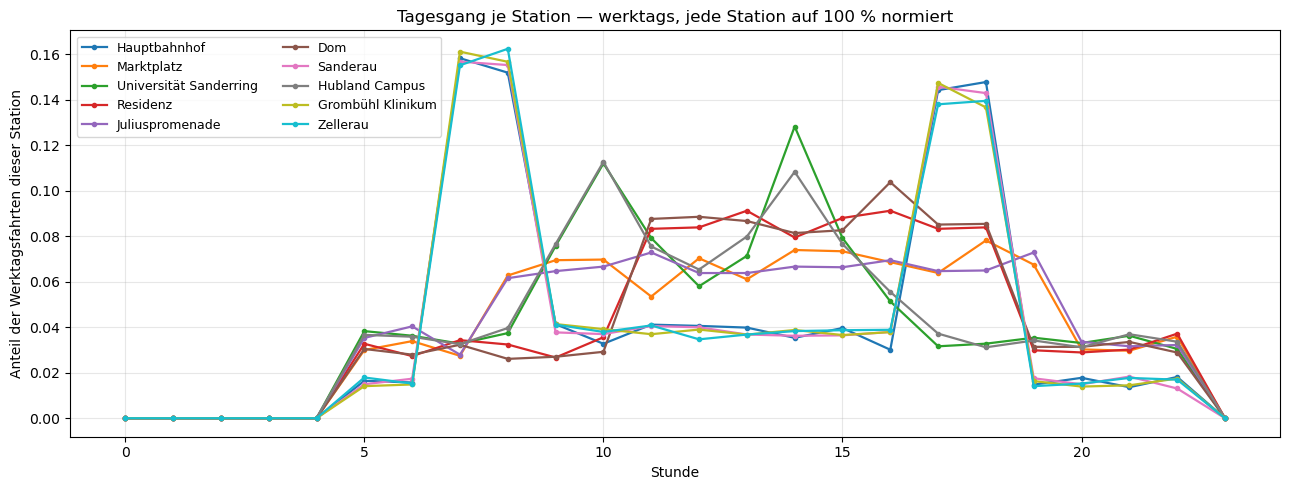

In [3]:
werktags = echte[~echte.ist_frei]
tagesgang = werktags.pivot_table(index="start_station_id", columns="stunde",
                                 values="ausleihe_id", aggfunc="count").fillna(0)
# Zwischen 23 und 5 Uhr gibt es in den Daten keine Fahrt, die Stunden fehlen
# deshalb ganz. Das ist eine Aussage ueber die NACHFRAGE, nicht ueber die
# Verfuegbarkeit - ausleihen kann man rund um die Uhr, es tut nur niemand.
# Wir fuellen die Stunden ausdruecklich mit Null auf: ein Merkmalsvektor muss
# fuer jede Station dieselbe Laenge haben, und "keine Fahrten um 3 Uhr" ist
# eine Information, kein Loch.
tagesgang = tagesgang.reindex(columns=range(24), fill_value=0)
tagesgang = tagesgang.div(tagesgang.sum(axis=1), axis=0)      # je Station auf 1 normiert
print(f"Stunden mit Fahrten: {int((tagesgang.sum() > 0).sum())} von 24")
namen = stationen.set_index("station_id").name

plt.figure(figsize=(13, 5))
for sid in tagesgang.index:
    plt.plot(tagesgang.columns, tagesgang.loc[sid], marker=".", lw=1.6, label=namen[sid])
plt.xlabel("Stunde"); plt.ylabel("Anteil der Werktagsfahrten dieser Station")
plt.title("Tagesgang je Station — werktags, jede Station auf 100 % normiert")
plt.legend(ncol=2, fontsize=9); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Das Bild beantwortet die Frage:** Es gibt mindestens drei erkennbar verschiedene
Formen — scharfe Doppelspitzen morgens und abends, ein breiter Vormittagsberg, und flache
Nachmittagskurven. Ein Clustering hat also Substanz.

> **Warum wir normieren:** Ohne die Normierung würde der Hauptbahnhof alle anderen
> überragen, und das Clustering würde vor allem **Größe** gruppieren statt **Form**.
> Wir wollen aber wissen, *wann* eine Station genutzt wird, nicht *wieviel*. Das ist eine
> inhaltliche Entscheidung, die in Phase 3 gehört — hier sieht man, warum.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** A) Aus Fahrten wird ein Tagesgang je Station. B) Aus Fahrten wird ein RFM-Profil je Kunde. Beides ist Aggregation — und beides braucht Standardisierung.

### 3.A Merkmale je Station

Wir geben jeder Station **26 Zahlen** mit: 24 für den normierten Tagesgang, dazu den
Wochenendanteil und die mittlere Fahrtdauer.

In [4]:
tagesgang.columns = [f"stunde_{h:02d}" for h in tagesgang.columns]
echte["dauer_min"] = (echte.endzeit - echte.startzeit).dt.total_seconds() / 60

zusatz = echte.groupby("start_station_id").agg(
    wochenendanteil=("ist_frei", "mean"),
    dauer_median=("dauer_min", "median"),
    fahrten_gesamt=("ausleihe_id", "size"),
)
S = tagesgang.join(zusatz)
S.index = [namen[i] for i in S.index]
print(S[["wochenendanteil", "dauer_median", "fahrten_gesamt"]].round(2).to_string())

                        wochenendanteil  dauer_median  fahrten_gesamt
Hauptbahnhof                       0.15           8.0            6298
Marktplatz                         0.34          13.0            5401
Universität Sanderring             0.14           8.0            4013
Residenz                           0.56          29.0            7148
Juliuspromenade                    0.34          13.0            5323
Dom                                0.56          29.0            7254
Sanderau                           0.16           8.0            6375
Hubland Campus                     0.14           8.0            4241
Grombühl Klinikum                  0.16           8.0            6402
Zellerau                           0.17           8.0            6282


Schon diese drei Spalten trennen sichtbar: Der Wochenendanteil reicht von rund 11 % bis
knapp 50 %. Das wird gleich ein starkes Merkmal sein.

### Standardisieren — und warum das hier zwingend ist

In [5]:
from sklearn.preprocessing import StandardScaler

merkmale_station = [s for s in S.columns if s != "fahrten_gesamt"]
print("Größenordnungen VOR der Standardisierung:")
print(S[merkmale_station].describe().loc[["mean", "std"]].round(3).T.head(6).to_string())

S_skaliert = StandardScaler().fit_transform(S[merkmale_station])

print(f"\nNach der Standardisierung: Mittelwert {S_skaliert.mean():.2f}, "
      f"Streuung {S_skaliert.std():.2f}")

Größenordnungen VOR der Standardisierung:
            mean   std
stunde_00  0.000  0.00
stunde_01  0.000  0.00
stunde_02  0.000  0.00
stunde_03  0.000  0.00
stunde_04  0.000  0.00
stunde_05  0.027  0.01

Nach der Standardisierung: Mittelwert 0.00, Streuung 0.88


> **Warum das nicht optional ist.** k-Means misst Abstände. Der Wochenendanteil liegt
> zwischen 0 und 0,5, die mittlere Fahrtdauer zwischen 10 und 25 — ohne Standardisierung
> wäre die Fahrtdauer allein durch ihre **Maßeinheit** rund fünfzigmal wichtiger als der
> Wochenendanteil. Das Verfahren würde dann nicht das Wichtigste gruppieren, sondern das
> Großzahligste.

### 3.B Merkmale je Kunde: das RFM-Modell

Für die Kundschaft nehmen wir ein Verfahren, das im Handel seit Jahrzehnten Standard ist
und ohne jede Statistikkenntnis erklärbar bleibt — **RFM**:

| | steht für | hier gemessen als |
|---|---|---|
| **R**ecency | Wie lange ist der letzte Kauf her? | Tage seit der letzten Fahrt |
| **F**requency | Wie oft wird gekauft? | Fahrten in den letzten 365 Tagen |
| **M**onetary | Wieviel wird ausgegeben? | Entgelt in den letzten 365 Tagen |

In [6]:
stichtag = echte.startzeit.max().normalize()
fenster = echte[echte.startzeit > stichtag - pd.Timedelta(days=365)]

rfm = fenster.groupby("kunde_id").agg(
    letzte_fahrt=("startzeit", "max"),
    frequenz=("ausleihe_id", "size"),
    umsatz=("entgelt_eur", "sum"),
)
rfm["recency"] = (stichtag - rfm.letzte_fahrt).dt.days.clip(lower=0)
rfm = rfm.join(kunden.set_index("kunde_id")[["tarif_code", "geburtsjahr", "registriert_am"]])

print(f"Stichtag: {stichtag.date()}, Fenster: letzte 365 Tage")
print(f"Kundschaft mit mindestens einer Fahrt darin: {len(rfm)} von {len(kunden)}")
print(f"ohne jede Fahrt im Fenster: {len(kunden) - len(rfm)} — die betrachten wir gleich gesondert\n")
print(rfm[["recency", "frequenz", "umsatz"]].describe().round(1).to_string())

Stichtag: 2026-08-24, Fenster: letzte 365 Tage
Kundschaft mit mindestens einer Fahrt darin: 2202 von 3200
ohne jede Fahrt im Fenster: 998 — die betrachten wir gleich gesondert

       recency  frequenz  umsatz
count   2202.0    2202.0  2202.0
mean      58.5       9.0    15.2
std       82.3       8.5    21.1
min        0.0       1.0     0.1
25%       11.0       3.0     3.4
50%       29.0       6.0     7.4
75%       61.0      12.0    18.3
max      364.0      50.0   279.2


### Die schiefe Verteilung — und was man dagegen tut

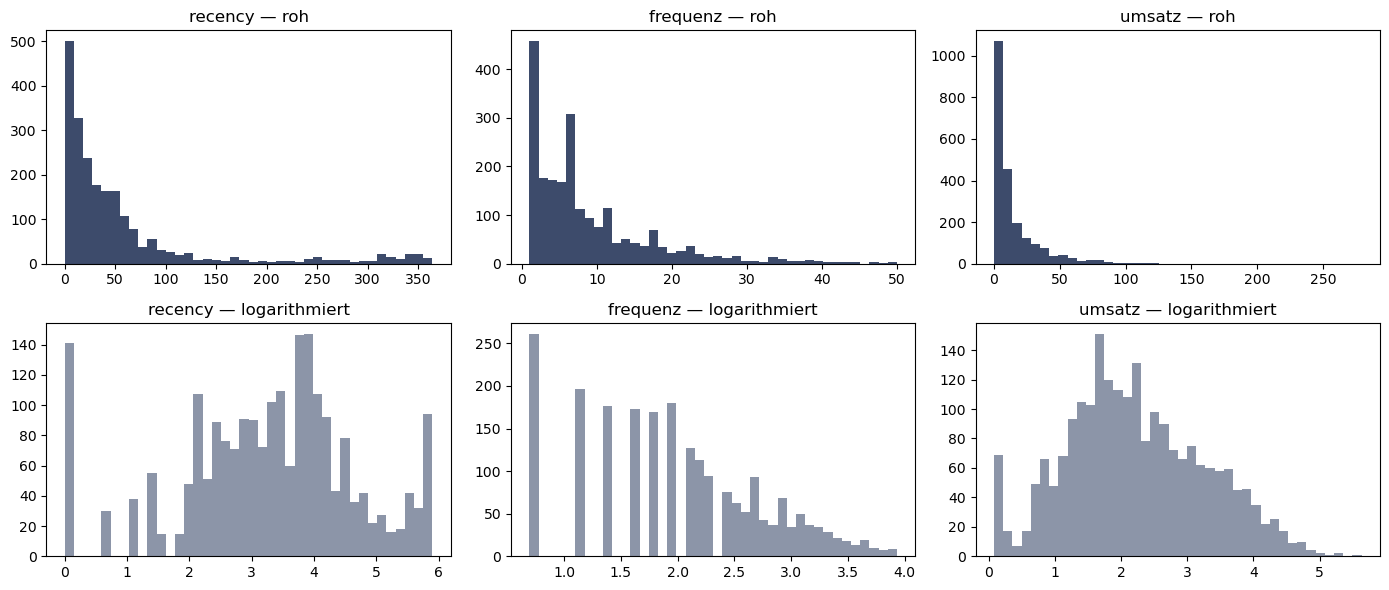

Frequenz und Umsatz gehen logarithmiert ein, Recency roh.


In [7]:
fig, achsen = plt.subplots(2, 3, figsize=(14, 6))
for spalte, achse in zip(["recency", "frequenz", "umsatz"], achsen[0]):
    achse.hist(rfm[spalte], bins=40, color="#3d4b6b")
    achse.set_title(f"{spalte} — roh")
for spalte, achse in zip(["recency", "frequenz", "umsatz"], achsen[1]):
    achse.hist(np.log1p(rfm[spalte]), bins=40, color="#8c95a8")
    achse.set_title(f"{spalte} — logarithmiert")
plt.tight_layout(); plt.show()

R = rfm[["recency", "frequenz", "umsatz"]].copy()
R["frequenz"] = np.log1p(R.frequenz)
R["umsatz"] = np.log1p(R.umsatz)
R_skaliert = StandardScaler().fit_transform(R)
print("Frequenz und Umsatz gehen logarithmiert ein, Recency roh.")

**Frequenz und Umsatz sind stark rechtsschief**: sehr viele kleine Werte, wenige sehr
große. k-Means würde sich an den wenigen Extremfällen festbeißen und aus ihnen eigene
Cluster machen — und die restlichen 95 % in einen Topf werfen.

Der Logarithmus zieht den Ausläufer zusammen (untere Reihe) und macht aus „hundertmal so
viel“ ein handhabbares „doppelt so weit weg“. **Recency lassen wir roh**, weil sie ohnehin
gleichmäßiger verteilt ist und ihre Einheit — Tage — anschaulich bleibt.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** k-Means für beide Aufgaben. Die eigentliche Frage lautet: **wie viele Gruppen?**

### 4.1 Wie k-Means arbeitet — in vier Sätzen

1. Wirf *k* Punkte zufällig in den Merkmalsraum („Zentren“).
2. Ordne jedes Objekt dem nächstgelegenen Zentrum zu.
3. Verschiebe jedes Zentrum in die Mitte der ihm zugeordneten Objekte.
4. Wiederhole 2 und 3, bis sich nichts mehr bewegt.

Mehr ist es nicht. Die Schwierigkeit liegt nicht im Verfahren, sondern in der Frage, die
es **nicht** beantwortet: wie groß *k* sein soll.

### 4.2 Die Ellenbogenmethode und der Silhouettenwert

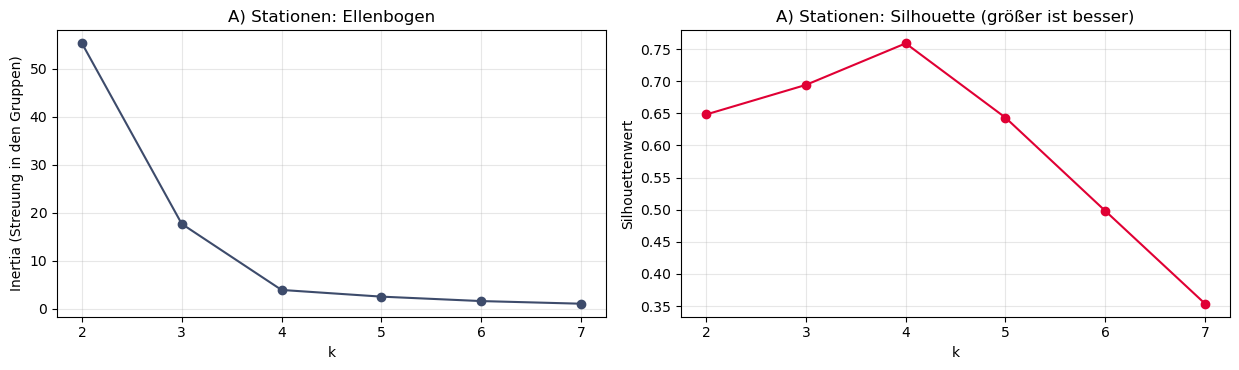

 k  Inertia  Silhouette
 2     55.3       0.648
 3     17.7       0.694
 4      4.0       0.759
 5      2.6       0.643
 6      1.6       0.498
 7      1.1       0.354


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def k_suchen(X, titel, ks=range(2, 8)):
    inertia, silhouette = [], []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=25, random_state=42).fit(X)
        inertia.append(km.inertia_)
        silhouette.append(silhouette_score(X, km.labels_))
    fig, achsen = plt.subplots(1, 2, figsize=(12.5, 3.8))
    achsen[0].plot(list(ks), inertia, marker="o", color="#3d4b6b")
    achsen[0].set_xlabel("k"); achsen[0].set_ylabel("Inertia (Streuung in den Gruppen)")
    achsen[0].set_title(f"{titel}: Ellenbogen"); achsen[0].grid(alpha=.3)
    achsen[1].plot(list(ks), silhouette, marker="o", color="#e00034")
    achsen[1].set_xlabel("k"); achsen[1].set_ylabel("Silhouettenwert")
    achsen[1].set_title(f"{titel}: Silhouette (größer ist besser)"); achsen[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()
    return pd.DataFrame({"k": list(ks), "Inertia": np.round(inertia, 1),
                         "Silhouette": np.round(silhouette, 3)})

print(k_suchen(S_skaliert, "A) Stationen").to_string(index=False))

**Die Inertia fällt immer** — bei *k* = 10 wäre sie null, denn dann ist jede Station ihr
eigenes Cluster. Gesucht ist der **Knick**: die Stelle, ab der zusätzliche Gruppen kaum
noch Streuung wegnehmen.

Der Silhouettenwert misst etwas anderes: Wie viel näher liegt ein Objekt bei seiner
eigenen Gruppe als bei der nächstbesten? Werte über 0,5 gelten als deutliche Struktur.

> **Beide Maße sind Hinweise, keine Entscheidungen.** Die Entscheidung fällt in Phase 5
> und stützt sich auf die Kriterien aus Phase 1 — vor allem auf die Benennbarkeit.

Ergebnis mit k = 4:

  Cluster 0: Residenz, Dom
  Cluster 1: Hauptbahnhof, Sanderau, Grombühl Klinikum, Zellerau
  Cluster 2: Marktplatz, Juliuspromenade
  Cluster 3: Universität Sanderring, Hubland Campus


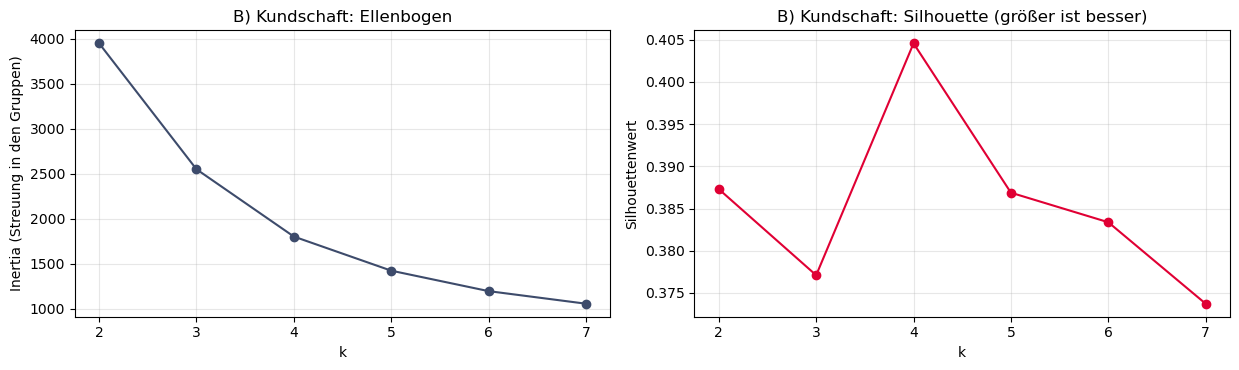

 k  Inertia  Silhouette
 2   3950.5       0.387
 3   2551.2       0.377
 4   1803.4       0.405
 5   1424.4       0.387
 6   1197.1       0.383
 7   1057.3       0.374


In [9]:
K_STATIONEN = 4
km_stationen = KMeans(n_clusters=K_STATIONEN, n_init=25, random_state=42).fit(S_skaliert)
S["cluster"] = km_stationen.labels_

print(f"Ergebnis mit k = {K_STATIONEN}:\n")
for c in sorted(S.cluster.unique()):
    mitglieder = list(S.index[S.cluster == c])
    print(f"  Cluster {c}: {', '.join(mitglieder)}")

print(k_suchen(R_skaliert, "B) Kundschaft").to_string(index=False))

In [10]:
K_KUNDEN = 4
km_kunden = KMeans(n_clusters=K_KUNDEN, n_init=25, random_state=42).fit(R_skaliert)
rfm["cluster"] = km_kunden.labels_

profil = rfm.groupby("cluster").agg(
    kunden=("frequenz", "size"),
    recency_tage=("recency", "mean"),
    fahrten_jahr=("frequenz", "mean"),
    umsatz_jahr=("umsatz", "mean"),
).round(1)
profil["anteil"] = (profil.kunden / profil.kunden.sum() * 100).round(1)
print(profil.to_string())

         kunden  recency_tage  fahrten_jahr  umsatz_jahr  anteil
cluster                                                         
0           538          37.0           7.5         41.2    24.4
1           776          49.2           4.2          3.8    35.2
2           216         282.6           1.6          5.3     9.8
3           672          14.4          18.1         10.7    30.5


---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Ohne Zielgröße gibt es keine Trefferquote. Es gibt aber die vier Kriterien aus Phase 1 — und die sind streng genug.

### 5.A Stationen: ergeben die Gruppen fachlich Sinn?

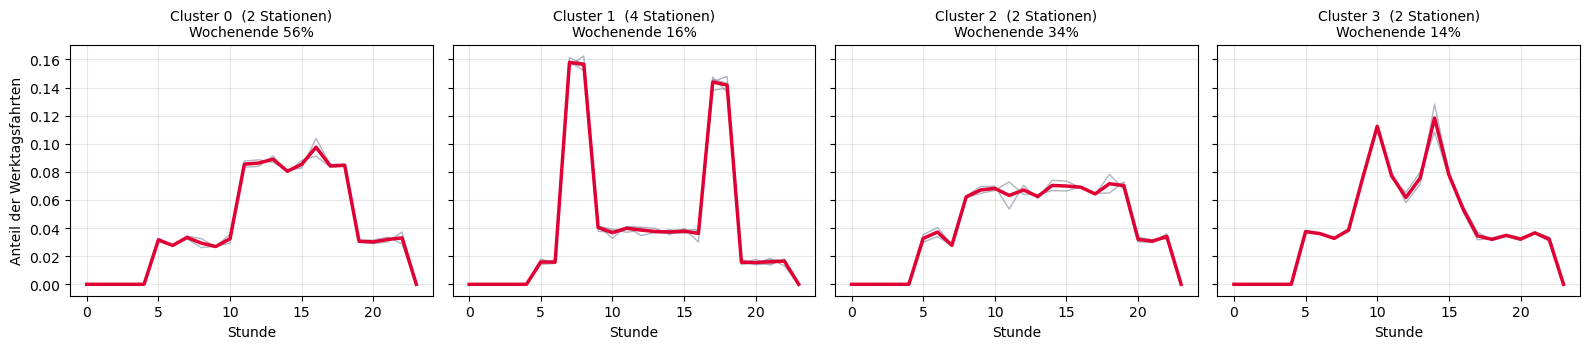

Cluster 0: Residenz, Dom                                                  Spitze 16 Uhr, Wochenende 56%, Dauer 29 Min
Cluster 1: Hauptbahnhof, Sanderau, Grombühl Klinikum, Zellerau            Spitze  7 Uhr, Wochenende 16%, Dauer 8 Min
Cluster 2: Marktplatz, Juliuspromenade                                    Spitze 18 Uhr, Wochenende 34%, Dauer 13 Min
Cluster 3: Universität Sanderring, Hubland Campus                         Spitze 14 Uhr, Wochenende 14%, Dauer 8 Min


In [11]:
fig, achsen = plt.subplots(1, K_STATIONEN, figsize=(16, 3.6), sharey=True)
stundenspalten = [s for s in S.columns if s.startswith("stunde_")]
for c, achse in zip(sorted(S.cluster.unique()), achsen):
    gruppe = S[S.cluster == c]
    for name in gruppe.index:
        achse.plot(range(24), gruppe.loc[name, stundenspalten].values,
                   color="#8c95a8", lw=1, alpha=.7)
    achse.plot(range(24), gruppe[stundenspalten].mean().values, color="#e00034", lw=2.5)
    achse.set_title(f"Cluster {c}  ({len(gruppe)} Stationen)\n"
                    f"Wochenende {gruppe.wochenendanteil.mean():.0%}", fontsize=10)
    achse.set_xlabel("Stunde"); achse.grid(alpha=.3)
achsen[0].set_ylabel("Anteil der Werktagsfahrten")
plt.tight_layout(); plt.show()

for c in sorted(S.cluster.unique()):
    g = S[S.cluster == c]
    spitze = int(g[stundenspalten].mean().values.argmax())
    print(f"Cluster {c}: {', '.join(g.index):<62s} Spitze {spitze:>2d} Uhr, "
          f"Wochenende {g.wochenendanteil.mean():.0%}, Dauer {g.dauer_median.mean():.0f} Min")

### Die Gruppen benennen — Kriterium 1 aus Phase 1

Jetzt kommt der Schritt, den kein Algorithmus abnimmt. Die Zahlen liefern Gruppen; **die
Namen liefert der Verstand.** Lesen Sie die vier Kurven und die Zeile darunter:

- vier Stationen mit **Spitze um 7 Uhr** und einem Wochenendanteil von **16 %** — das
  sind Wege zur Arbeit: **Pendlerstationen**
- zwei Stationen mit **Spitze um 14 Uhr**, Wochenende noch niedriger bei **14 %** — das
  folgt dem Vorlesungsbetrieb: **Uni-Stationen**
- zwei Stationen mit **Spitze um 16 Uhr**, Wochenendanteil **56 %** und mit 29 Minuten
  der doppelten Fahrtdauer — das ist Freizeit: **Ausflugsstationen**
- zwei Stationen, die **zwischen allem** liegen: Marktplatz und Juliuspromenade, Spitze
  um 18 Uhr, Wochenendanteil 34 % — **Innenstadtstationen**

Die Zahlen stehen in der Tabelle darüber; lesen Sie sie nach, statt der Aufzählung zu
glauben.

**Kriterien 1 bis 3 aus Phase 1 sind damit erfüllt:** Jede Gruppe ist benennbar, jede
bekommt in Phase 6 eine eigene Regel, und keine ist zu klein. Kriterium 2 wird dort
außerdem maschinell geprüft — **vier Gruppen müssen vier verschiedene Maßnahmen
ergeben.** Eine frühere Fassung dieses Notebooks hat genau daran gescheitert, ohne dass
es auffiel.

### Kriterium 4: Stabilität — gemessen, nicht behauptet

`n_init=25` ist **keine** Stabilitätsprüfung. Es rechnet 25 Startpunkte durch und nimmt
den mit der geringsten Streuung — das ist Qualitätssicherung innerhalb eines Laufs, nicht
die Frage, ob ein anderer Zufallsstart dieselben Gruppen liefert.

Die Frage lässt sich beantworten: Man clustert mehrfach mit verschiedenen Startwerten und
vergleicht die Einteilungen mit dem **adjustierten Rand-Index**. Er ist 1,0 bei
identischer Gruppierung und 0 bei zufälliger Übereinstimmung.

In [12]:
from sklearn.metrics import adjusted_rand_score

def stabilitaet(daten, k, name):
    """Liefern andere Zufallsstarts dieselbe Einteilung?"""
    grund = KMeans(n_clusters=k, n_init=25, random_state=42).fit_predict(daten)
    werte = []
    for seed in (0, 1, 7, 99, 2024):
        andere = KMeans(n_clusters=k, n_init=25, random_state=seed).fit_predict(daten)
        werte.append(adjusted_rand_score(grund, andere))
    print(f"{name:14s} ARI über fünf Startwerte: "
          f"{min(werte):.3f} bis {max(werte):.3f}   "
          f"{'stabil' if min(werte) > 0.99 else 'nur annähernd stabil'}")
    return min(werte)

s_stab = stabilitaet(S_skaliert, K_STATIONEN, "Stationen")
k_stab = stabilitaet(R_skaliert, K_KUNDEN, "Kundschaft")

Stationen      ARI über fünf Startwerte: 1.000 bis 1.000   stabil


Kundschaft     ARI über fünf Startwerte: 0.895 bis 0.993   nur annähernd stabil


**Die Stationen sind stabil, die Kundensegmente nur annähernd.** Bei den zehn Stationen
liefert jeder Startwert dieselbe Einteilung. Bei 2.202 Kundinnen und Kunden wandern je
nach Startwert einzelne Personen zwischen den Gruppen — der ARI bleibt hoch, erreicht
aber nicht 1,0.

Für die Auslieferung heißt das: Der Dispositionsplan ist eine feste Zuordnung, der
Kampagnenplan ist es nicht. Wer nächstes Quartal neu clustert, bekommt bei einzelnen
Kunden ein anderes Segment. **Deshalb wird der Kampagnenplan in Phase 6 nicht über
Cluster-Nummern ausgeliefert, sondern über nachvollziehbare Schwellen** — die sind
reproduzierbar.

> **Und noch eine Zahl, die man nicht überlesen sollte:** Der Silhouettenwert der
> Kundensegmente liegt bei 0,405, der der Stationen bei 0,759. Werte um 0,4 heißen:
> Es *gibt* eine Struktur, aber die Gruppen gehen ineinander über. Das ist bei
> Kundendaten der Normalfall und kein Fehler — es ist aber ein Grund, die Segmente als
> Arbeitshilfe zu behandeln und nicht als Naturkonstante.

> **Bei den Stationen stimmen Kennzahl und Fachlichkeit überein** — der Silhouettenwert
> ist bei k = 4 am höchsten, und die vier Gruppen lassen sich benennen. Das ist der
> angenehme Fall.
>
> **Verlassen kann man sich darauf nicht.** Bei der Kundensegmentierung weiter unten liegen
> die Silhouettenwerte für k = 2, k = 4 und k = 5 dicht beieinander; dort entscheidet die
> Kennzahl gar nichts, und die vier Kriterien aus Phase 1 sind das Einzige, was bleibt.
> Wer nur auf die Kennzahl schaut, hat kein Verfahren für den Fall, dass sie schweigt.
>
> Entschieden hat **Kriterium 2**: Für jede Gruppe muss es eine andere Maßnahme geben.
> Bei k = 2 gibt es sie nicht, bei k = 4 schon. Das ist keine Schwäche des Verfahrens,
> sondern die Arbeitsteilung: Die Statistik liefert Kandidaten, die Fachlichkeit
> entscheidet.

In [13]:
# EIN BLICK, DEN ES IM ECHTEN PROJEKT NICHT GIBT
# Dieser Datensatz wurde erzeugt - und zwar mit genau vier Stationstypen, die
# in KEINER CSV stehen. Deshalb koennen wir hier ausnahmsweise nachsehen, ob
# das Clustering sie wiedergefunden hat. Im Betrieb ist das unmoeglich; dort
# bleibt es beim fachlichen Urteil oben.
ERZEUGT_ALS = {
    "Hauptbahnhof": "pendler", "Zellerau": "pendler",
    "Grombühl Klinikum": "pendler", "Sanderau": "pendler",
    "Universität Sanderring": "uni", "Hubland Campus": "uni",
    "Residenz": "freizeit", "Dom": "freizeit",
    "Juliuspromenade": "misch",
    "Marktplatz": "misch",
}
pruefung = pd.DataFrame({"gefunden": S.cluster,
                         "erzeugt_als": [ERZEUGT_ALS[n] for n in S.index]})
kreuz = pd.crosstab(pruefung.gefunden, pruefung.erzeugt_als)
print(kreuz.to_string())
treffer = kreuz.max(axis=1).sum() / kreuz.values.sum()
print(f"\nÜbereinstimmung: {treffer:.0%} — jede gefundene Gruppe entspricht genau einem erzeugten Typ.")

erzeugt_als  freizeit  misch  pendler  uni
gefunden                                  
0                   2      0        0    0
1                   0      0        4    0
2                   0      2        0    0
3                   0      0        0    2

Übereinstimmung: 100% — jede gefundene Gruppe entspricht genau einem erzeugten Typ.


> **Diese Zelle ist ein Luxus des Lehrdatensatzes.** In einem echten Projekt gibt es
> keine Tabelle, gegen die man prüfen könnte — hätten wir sie, bräuchten wir kein
> Clustering. Sie steht hier nur, um zu zeigen, dass die fachliche Deutung oben nicht
> Wunschdenken war.

### 5.B Kundschaft: die Segmente lesen

         kunden  recency_tage  fahrten_jahr  umsatz_jahr  anteil  BASIS  OEPNV  PREMIUM  STUDENT
cluster                                                                                         
0           538          37.0           7.5         41.2    24.4   99.0    1.0      0.0      0.0
1           776          49.2           4.2          3.8    35.2   24.0   17.0     14.0     45.0
2           216         282.6           1.6          5.3     9.8   67.0   10.0      7.0     16.0
3           672          14.4          18.1         10.7    30.5    4.0   36.0     40.0     19.0


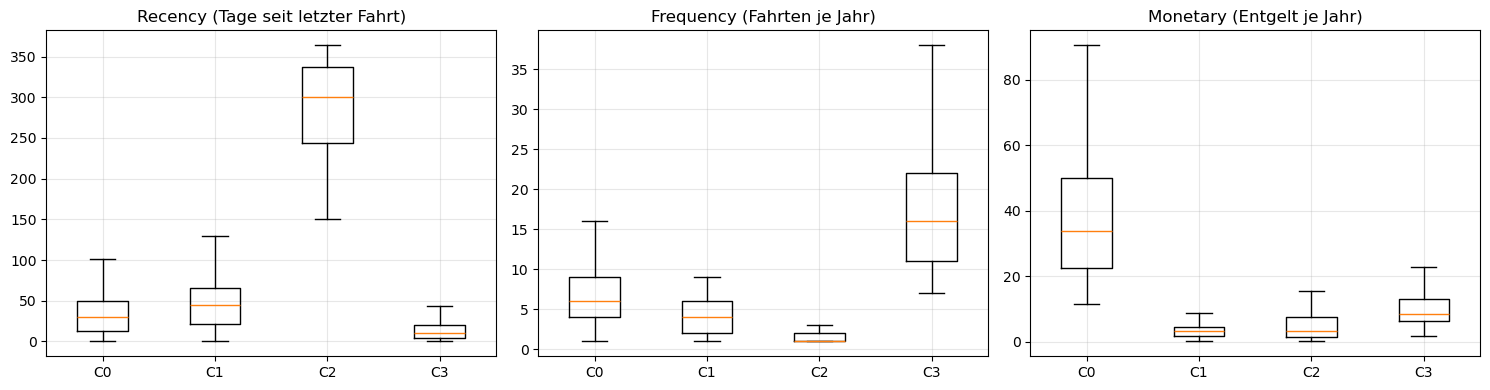

In [14]:
tarifverteilung = (rfm.groupby("cluster").tarif_code.value_counts(normalize=True)
                   .unstack().fillna(0) * 100).round(0)
uebersicht = profil.join(tarifverteilung)
print(uebersicht.to_string())

fig, achsen = plt.subplots(1, 3, figsize=(15, 4))
for spalte, achse, titel in zip(["recency", "frequenz", "umsatz"], achsen,
                                ["Recency (Tage seit letzter Fahrt)",
                                 "Frequency (Fahrten je Jahr)", "Monetary (Entgelt je Jahr)"]):
    daten = [rfm.loc[rfm.cluster == c, spalte].values for c in sorted(rfm.cluster.unique())]
    achse.boxplot(daten, tick_labels=[f"C{c}" for c in sorted(rfm.cluster.unique())],
                  showfliers=False)
    achse.set_title(titel); achse.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.B.1 Ein Befund, der so nicht erwartet war

Sehen Sie sich die Spalten `fahrten_jahr` und `umsatz_jahr` nebeneinander an:

**Das Segment mit den meisten Fahrten hat den geringsten Umsatz.** Rund sechzehn Fahrten
im Jahr — und keine zehn Euro Entgelt. Das Segment mit halb so vielen Fahrten bringt das
**Fünf- bis Sechsfache**.

Ein Blick auf die Tarifverteilung erklärt es: Die Vielfahrer sitzen fast alle im
**OEPNV-Abo** oder im **Premium**-Tarif — mit 600 bzw. 1.000 Freiminuten im Monat. Sie
fahren viel und zahlen für die einzelne Fahrt fast nichts. Die Umsatzträger sind dagegen
zu 98 % **Basistarif**: keine Freiminuten, jede Minute wird berechnet.

> **„OEPNV-Abo“ meint das Abo des Kunden, nicht eines bei VeloCity.** Alle vier Tarife
> sind beitragsfrei; die drei Vorteilstarife bekommt man über einen Nachweis —
> Studierendenausweis, Nahverkehrsabo oder Rahmenvertrag über den Arbeitgeber. Die Spalte
> `voraussetzung` in `tarif.csv` nennt sie.

### 5.B.2 Das ist kein Messfehler — das ist ein Preisproblem

An dieser Stelle liegt die Versuchung nahe, nach einer fehlenden Umsatzkomponente zu
suchen: Zahlen die Vielfahrer nicht vielleicht einen Monatsbeitrag, den wir übersehen
haben?

**Nein.** VeloCity erhebt **keine Grundgebühr** — das ist Teil des Produktversprechens und
steht so auf der Startseite („0 Euro Anmeldegebühr“); die Preisauskunft nennt
ausschließlich *Startgebühr plus Minutenpreis, gedeckelt auf einen Tageshöchstpreis*. Das
Nutzungsentgelt **ist** der gesamte Umsatz.

Damit ist der Befund kein Fehler in unserer Merkmalsdefinition, sondern eine Aussage über
das Geschäft:

> **Die aktivsten Kundinnen und Kunden bringen am wenigsten ein — und niemand gleicht das
> aus.**

Rechnen wir aus, um wieviel es geht. In den Daten steht neben dem gezahlten Entgelt auch,
wie viele Minuten **berechnet** wurden. Die Differenz zur Fahrtdauer sind die verbrauchten
Freiminuten — und die haben einen Listenwert.

         kunden  fahrten_jahr  gezahlt  verschenkt  waere_gewesen  Anteil verschenkt
cluster                                                                             
0           538          7.48    41.18        1.58          42.76              0.037
1           776          4.16     3.75       13.12          16.87              0.778
2           216          1.61     5.31        2.27           7.58              0.299
3           672         18.07    10.74       40.61          51.35              0.791

Im letzten Jahr über Freiminuten abgegeben: 38.813 EUR Listenwert
Das sind 54% dessen, was ohne Freiminuten fällig gewesen wäre.


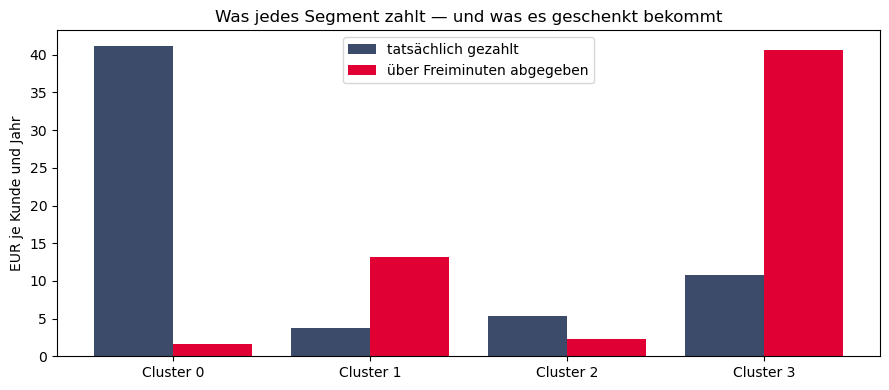

In [15]:
raeder = pd.read_csv(BASIS + "fahrrad.csv")
preise = pd.read_csv(BASIS + "nutzungspreis.csv").set_index("typ_code")

fenster2 = fenster.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
fenster2["dauer_min"] = (fenster2.endzeit - fenster2.startzeit).dt.total_seconds() / 60
fenster2["freiminuten"] = (fenster2.dauer_min - fenster2.berechnete_minuten).clip(lower=0)
fenster2["verschenkt_eur"] = (fenster2.freiminuten
                              * fenster2.typ_code.map(preise.preis_pro_minute_eur))

je_kunde = fenster2.groupby("kunde_id").verschenkt_eur.sum()
rfm["verschenkt"] = je_kunde.reindex(rfm.index).fillna(0)

vergleich = rfm.groupby("cluster").agg(
    kunden=("umsatz", "size"),
    fahrten_jahr=("frequenz", "mean"),
    gezahlt=("umsatz", "mean"),
    verschenkt=("verschenkt", "mean"),
).round(2)
vergleich["waere_gewesen"] = (vergleich.gezahlt + vergleich.verschenkt).round(2)
vergleich["Anteil verschenkt"] = (vergleich.verschenkt / vergleich.waere_gewesen).round(3)
print(vergleich.to_string())

gesamt_verschenkt = rfm.verschenkt.sum()
gesamt_gezahlt = rfm.umsatz.sum()
betrag = f"{gesamt_verschenkt:,.0f}".replace(",", ".")
anteil = gesamt_verschenkt / (gesamt_gezahlt + gesamt_verschenkt)
print()
print(f"Im letzten Jahr über Freiminuten abgegeben: {betrag} EUR Listenwert")
print(f"Das sind {anteil:.0%} dessen, was ohne Freiminuten fällig gewesen wäre.")

plt.figure(figsize=(9, 4))
x = np.arange(len(vergleich))
plt.bar(x - 0.2, vergleich.gezahlt, 0.4, label="tatsächlich gezahlt", color="#3d4b6b")
plt.bar(x + 0.2, vergleich.verschenkt, 0.4, label="über Freiminuten abgegeben", color="#e00034")
plt.xticks(x, [f"Cluster {c}" for c in vergleich.index])
plt.ylabel("EUR je Kunde und Jahr"); plt.legend()
plt.title("Was jedes Segment zahlt — und was es geschenkt bekommt")
plt.tight_layout(); plt.show()

**Jetzt ist das Bild vollständig, ohne dass wir eine Zahl erfinden mussten.** Das Segment
mit den meisten Fahrten zahlt am wenigsten *und* bekommt am meisten geschenkt. Beides
zusammen erklärt den Befund vollständig.

> **Für CRISP-DM ist dieser Moment lehrbuchreif** — allerdings anders, als man zunächst
> vermutet. Die Evaluation deckt **keinen** Fehler im Modell und keinen in der
> Merkmalsdefinition auf. Sie deckt eine **Geschäftsfrage** auf, die vor der Analyse
> niemand gestellt hatte: *Sind die Freiminuten dort richtig eingesetzt, wo sie liegen?*
>
> Der Pfeil führt trotzdem zurück nach Phase 1 — nicht um einen Fehler zu beheben,
> sondern weil die Analyse eine bessere Frage hervorgebracht hat als die, mit der sie
> begonnen hat. Das ist der häufigere und wertvollere Fall.

### 5.B.3 Eine Idee für die Geschäftsführung — ausdrücklich als Vorschlag

Die folgende Rechnung ist **kein Befund aus den Daten**, sondern ein Was-wäre-wenn. Sie
gehört in eine Entscheidungsvorlage, nicht in einen Analysebericht — und muss als
Vorschlag gekennzeichnet sein, sonst liest sie jemand als Tatsache.

In [16]:
# ACHTUNG: hypothetisch. VeloCity hat KEINE Grundgebühr, und das ist Teil
# des Kundenversprechens. Die Rechnung zeigt nur, welche Groessenordnung ein
# Beitrag haette, der die abgegebenen Minuten ausgleicht.
mit_freiminuten = rfm[rfm.verschenkt > 0]
je_monat = mit_freiminuten.verschenkt.mean() / 12

print("HYPOTHESE, kein Befund:")
print(f"  Kundschaft mit Freiminuten:            {len(mit_freiminuten):>6d}")
print(f"  im Mittel abgegeben, je Jahr:          {mit_freiminuten.verschenkt.mean():>6.2f} EUR")
print(f"  ein ausgleichender Beitrag laege bei:  {je_monat:>6.2f} EUR im Monat")
print()
print("  Zu bedenken, bevor daraus ein Vorschlag wird:")
print("   - die Startseite wirbt ausdrücklich mit '0 Euro Anmeldegebühr'")
print("   - Freiminuten binden Kundschaft; ihr Wert steckt nicht nur im Umsatz")
print("   - ein Beitrag würde die günstigsten Segmente am härtesten treffen")
print()
print("  Die billigere Alternative: die Freiminuten dort kürzen, wo sie am")
print("  wenigsten binden - das lässt sich mit denselben Daten prüfen.")

HYPOTHESE, kein Befund:
  Kundschaft mit Freiminuten:              1313
  im Mittel abgegeben, je Jahr:           29.56 EUR
  ein ausgleichender Beitrag laege bei:    2.46 EUR im Monat

  Zu bedenken, bevor daraus ein Vorschlag wird:
   - die Startseite wirbt ausdrücklich mit '0 Euro Anmeldegebühr'
   - Freiminuten binden Kundschaft; ihr Wert steckt nicht nur im Umsatz
   - ein Beitrag würde die günstigsten Segmente am härtesten treffen

  Die billigere Alternative: die Freiminuten dort kürzen, wo sie am
  wenigsten binden - das lässt sich mit denselben Daten prüfen.


### 5.B.4 Und die Kundschaft ganz ohne Fahrt?

In [17]:
ohne_fahrt = kunden[~kunden.kunde_id.isin(rfm.index)].copy()
ohne_fahrt["tage_seit_anmeldung"] = (stichtag - ohne_fahrt.registriert_am).dt.days
print(f"{len(ohne_fahrt)} Kundinnen und Kunden hatten im letzten Jahr keine einzige Fahrt.")
print(f"Das sind {len(ohne_fahrt)/len(kunden):.0%} des Bestands.\n")
print("Wie lange sind sie schon angemeldet?")
print(ohne_fahrt.tage_seit_anmeldung.describe().round(0).to_string())
print("\nTarifverteilung:")
print((ohne_fahrt.tarif_code.value_counts(normalize=True) * 100).round(0).to_string())

998 Kundinnen und Kunden hatten im letzten Jahr keine einzige Fahrt.
Das sind 31% des Bestands.

Wie lange sind sie schon angemeldet?
count     998.0
mean      944.0
std       419.0
min        32.0
25%       646.0
50%      1098.0
75%      1288.0
max      1487.0

Tarifverteilung:
tarif_code
BASIS      79.0
STUDENT    10.0
OEPNV       8.0
PREMIUM     3.0


**Diese Gruppe war in der Segmentierung gar nicht enthalten** — sie hat keine Fahrten,
also kein RFM-Profil. Sie ist aber mit knapp 30 % des Bestands die **größte Gruppe
überhaupt**, und für das Marketing die interessanteste: Wer nichts mehr fährt, ist
entweder verloren oder zurückzugewinnen.

> **Das ist der klassische Fehler bei RFM.** Das Verfahren betrachtet nur, wer gekauft
> hat. Wer aufgehört hat, fällt aus der Tabelle — und damit aus dem Blick. Man muss diese
> Gruppe ausdrücklich dazunehmen; sie kommt nicht von selbst.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Aus vier Stationstypen wird ein Umverteilungsplan, aus fünf Kundengruppen ein Kampagnenplan.

In [18]:
# --- A) Der Dispositionsplan
#
# Die Zuordnung folgt zwei Merkmalen: dem Wochenendanteil und der Uhrzeit
# der Spitze. Beide stehen in der Tabelle aus Phase 5 - hier wird nichts
# geraten, sondern abgelesen.
namen_cluster, regeln = {}, {}
for c in sorted(S.cluster.unique()):
    g = S[S.cluster == c]
    spitze = int(g[stundenspalten].mean().values.argmax())
    we = g.wochenendanteil.mean()
    if we > 0.45:
        bez, regel = "Ausflugsstation", "erst gegen 11 Uhr auffüllen, Schwerpunkt Sa/So"
    elif spitze <= 9:
        bez, regel = "Pendlerstation", "bis 6:30 Uhr voll, nachmittags Abfluss einplanen"
    elif we > 0.25:
        bez, regel = "Innenstadtstation", "abends nachlegen, am Wochenende halb so viel"
    else:
        bez, regel = "Uni-Station", "vorlesungsfreie Zeit: halbe Bestückung"
    namen_cluster[c], regeln[c] = bez, regel
    for name in g.index:
        print(f"{name:<22s} {bez:<18s} {regel}")

# ─── KRITERIUM 2 AUS PHASE 1, MASCHINELL GEPRUEFT ───────────────────
# "Fuer jede Gruppe muss es eine ANDERE Massnahme geben. Zwei Gruppen mit
# derselben Massnahme sind eine Gruppe."
#
# Diese Zeile ist aus Schaden entstanden: Eine frühere Fassung hatte einen
# Zweig zu wenig, und der Mischtyp fiel auf "Uni-Station" durch. Im
# ausgelieferten CSV standen dann vier Uni-Stationen statt zwei - und
# Marktplatz und Juliuspromenade bekamen die Anweisung "vorlesungsfreie
# Zeit: halbe Bestueckung", die fuer sie falsch ist. Aufgefallen ist es
# niemandem, weil der Text daneben etwas anderes behauptete.
assert len(set(namen_cluster.values())) == len(namen_cluster), (
    f"Kriterium 2 verletzt: {len(namen_cluster)} Gruppen, aber nur "
    f"{len(set(namen_cluster.values()))} verschiedene Bezeichnungen - "
    f"{namen_cluster}")
assert len(set(regeln.values())) == len(regeln), (
    f"Kriterium 2 verletzt: zwei Gruppen bekommen dieselbe Regel - {regeln}")
print(f"\nKriterium 2 geprüft: {len(namen_cluster)} Gruppen, "
      f"{len(set(regeln.values()))} verschiedene Maßnahmen.")

S["stationstyp"] = S.cluster.map(namen_cluster)
S[["stationstyp", "wochenendanteil", "dauer_median", "fahrten_gesamt"]].to_csv("stationstypen.csv")
print("geschrieben: stationstypen.csv")

Residenz               Ausflugsstation    erst gegen 11 Uhr auffüllen, Schwerpunkt Sa/So
Dom                    Ausflugsstation    erst gegen 11 Uhr auffüllen, Schwerpunkt Sa/So
Hauptbahnhof           Pendlerstation     bis 6:30 Uhr voll, nachmittags Abfluss einplanen
Sanderau               Pendlerstation     bis 6:30 Uhr voll, nachmittags Abfluss einplanen
Grombühl Klinikum      Pendlerstation     bis 6:30 Uhr voll, nachmittags Abfluss einplanen
Zellerau               Pendlerstation     bis 6:30 Uhr voll, nachmittags Abfluss einplanen
Marktplatz             Innenstadtstation  abends nachlegen, am Wochenende halb so viel
Juliuspromenade        Innenstadtstation  abends nachlegen, am Wochenende halb so viel
Universität Sanderring Uni-Station        vorlesungsfreie Zeit: halbe Bestückung
Hubland Campus         Uni-Station        vorlesungsfreie Zeit: halbe Bestückung

Kriterium 2 geprüft: 4 Gruppen, 4 verschiedene Maßnahmen.
geschrieben: stationstypen.csv


In [19]:
# --- B) Der Kampagnenplan
def segment_benennen(zeile):
    if zeile.recency_tage > 150:
        return "Eingeschlafen"
    if zeile.fahrten_jahr > 12:
        return "Vielfahrer mit Freiminuten"
    if zeile.umsatz_jahr > 30:
        return "Umsatzträger im Basistarif"
    return "Gelegenheitsnutzer"

profil["segment"] = profil.apply(segment_benennen, axis=1)
massnahmen = {
    "Vielfahrer mit Freiminuten":  "Bindung halten — aber prüfen, ob 1.000 Freiminuten nötig sind",
    "Umsatzträger im Basistarif":  "nicht anfassen: sie tragen den Umsatz und kosten nichts",
    "Gelegenheitsnutzer":    "Anlass schaffen: Wetter-/Veranstaltungshinweis",
    "Eingeschlafen":         "Rückgewinnung: einmalig Freiminuten",
}
plan = profil.copy()
plan["maßnahme"] = plan.segment.map(massnahmen)
print(plan[["segment", "kunden", "anteil", "recency_tage", "fahrten_jahr",
            "umsatz_jahr", "maßnahme"]].to_string(index=False))

print(f"\n{'Nie gefahren (nicht im RFM)':<24s} {len(ohne_fahrt):>5d} Kunden   "
      f"Maßnahme: Ansprache zur Erstfahrt, sonst Karteileiche")

                   segment  kunden  anteil  recency_tage  fahrten_jahr  umsatz_jahr                                                      maßnahme
Umsatzträger im Basistarif     538    24.4          37.0           7.5         41.2       nicht anfassen: sie tragen den Umsatz und kosten nichts
        Gelegenheitsnutzer     776    35.2          49.2           4.2          3.8                Anlass schaffen: Wetter-/Veranstaltungshinweis
             Eingeschlafen     216     9.8         282.6           1.6          5.3                           Rückgewinnung: einmalig Freiminuten
Vielfahrer mit Freiminuten     672    30.5          14.4          18.1         10.7 Bindung halten — aber prüfen, ob 1.000 Freiminuten nötig sind

Nie gefahren (nicht im RFM)   998 Kunden   Maßnahme: Ansprache zur Erstfahrt, sonst Karteileiche


### 6.1 Was bei diesen beiden Auslieferungen zu beachten ist

**Der Dispositionsplan** ist unkritisch: vier Regeln, die ein Mensch liest und befolgt.
Er muss aber **nachgerechnet werden**, wenn eine Station dazukommt — und dann kann sich
die Zuordnung *aller* Stationen ändern, weil k-Means alle Zentren neu setzt. Ein neues
Cluster-Ergebnis ist nie eine Ergänzung, immer eine Neuberechnung.

**Der Kampagnenplan** ist heikler, und zwar aus einem Grund, der nichts mit Statistik zu
tun hat:

> Kundensegmente sind **personenbezogene Daten**. Wer segmentiert, verarbeitet sie — und
> braucht dafür eine Rechtsgrundlage. Ein Segment „Eingeschlafen“ mit einer
> Rückgewinnungsmail ist Direktwerbung; ein Segment „zahlungsschwach“ wäre etwas ganz
> anderes. Die Grenze verläuft nicht dort, wo die Technik endet.

### 6.2 Überwachung

| Wache | Schwelle | Reaktion |
|---|---|---|
| Silhouettenwert bei Neuberechnung | fällt unter 0,35 | Struktur löst sich auf — k neu bestimmen |
| Größe des kleinsten Segments | unter 5 % | Kriterium 3 aus Phase 1 gerissen |
| Wanderung zwischen Segmenten | über 25 % je Quartal | Segmente sind nicht stabil, Kampagnen laufen ins Leere |
| Anteil ohne Fahrt im Fenster | steigt | das eigentliche Alarmsignal fürs Geschäft |

**Die letzte Zeile ist die wichtigste** und hat mit dem Modell nichts zu tun: Wenn die
Gruppe der Nichtfahrer wächst, ist das ein Geschäftsproblem, kein Analyseproblem.

---

# Der Kreislauf schließt sich

| Phase | A) Stationen | B) Kundschaft |
|---|---|---|
| 1 Business Understanding | Umverteilung nach Regeln statt nach Gefühl | Newsletter nach Segmenten statt an alle |
| | \multicolumn — gemeinsame Erfolgskriterien: benennbar, unterschiedlich behandelbar, groß genug, stabil | |
| 2 Data Understanding | Stammdaten enthalten keinen Typ — das Muster steckt im Verhalten | Kein Segment in der Kundentabelle |
| 3 Data Preparation | Tagesgang je Station, normiert und standardisiert | RFM über 365 Tage, Frequenz und Umsatz logarithmiert |
| 4 Modeling | k-Means, k über Ellenbogen und Silhouette | dasselbe Verfahren, dieselben Werkzeuge |
| 5 Evaluation | Vier benennbare Typen, gegen die verdeckte Wahrheit geprüft: 100 %. Stabilität gemessen, nicht behauptet | Vier Segmente, nur annähernd stabil und mit schwächerer Trennung — dazu zwei Befunde, die weh tun, und eine hypothetische Rechnung |
| 6 Deployment | Dispositionsplan als CSV | Kampagnenplan, mit Datenschutzvorbehalt |

**Die zwei Befunde aus Phase 5.B, die weh tun**

1. **Die Vielfahrer bringen den geringsten Umsatz** — weil ihre Tarife Freiminuten
   enthalten. Und weil VeloCity **keine Grundgebühr** erhebt, gibt es nichts, was das
   ausgliche: Das Nutzungsentgelt ist der gesamte Umsatz. Das ist kein Messfehler,
   sondern ein Preisproblem, das die Segmentierung sichtbar gemacht hat. Nachgerechnet
   ist auch, um wieviel es geht — der Listenwert der abgegebenen Freiminuten steht in
   den Daten.
2. **Knapp ein Drittel der Kundschaft taucht in der Segmentierung überhaupt nicht auf**, weil
   sie im letzten Jahr nicht gefahren ist. RFM sieht nur, wer kauft. Wer aufgehört hat,
   fällt aus der Tabelle — und aus dem Blick.

**Was eine zweite Runde anders machen würde**

1. **Zurück zu Phase 1, mit einer besseren Frage.** Nicht „welche Segmente gibt es?“,
   sondern „sind die Freiminuten dort richtig eingesetzt, wo sie liegen?“ — die Analyse
   hat eine Frage hervorgebracht, die vorher niemand gestellt hatte. Sauber wäre dafür
   ein **Deckungsbeitrag** statt des Entgelts: abzüglich der Kosten, die eine Fahrt
   verursacht (Umverteilung, Verschleiß, Strom).
2. **Zurück zu Phase 3:** Die Nichtfahrer als eigenes Segment mitführen, statt sie
   herausfallen zu lassen. RFM braucht dafür eine Erweiterung, oft „RFM + Status“ genannt.
3. **Ein anderes Verfahren erwägen:** k-Means unterstellt kugelförmige, gleich große
   Gruppen. Für Segmente mit sehr unterschiedlicher Streuung sind hierarchisches
   Clustering oder Gaussian Mixture Models oft passender.

**Weiter geht es mit Notebook 4 — Zeitreihe:** Dort kommt eine Größe dazu, die in diesem
Notebook keine Rolle spielte und alles verändert: **die Reihenfolge**. Wenn die Zukunft
vorhergesagt werden soll, darf man beim Aufteilen nicht mehr würfeln.